In [1]:
import logging
import os
import sys

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]
URL_AF = os.environ["API_URL_ALPHAFOLD_STRUCTPRED"]
sys.path.append(str(Path(INSTALL_PATH).resolve()))

# Modules
from modules.pymol_align import get_alphafold_structures, pymol_align_pairs

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

### Steps

1. Apply preliminary filtering criteria
2. Apply PyMOL alignment
3. Lookup how SMARCA4, KPNA2 fare

<br>

### Questions

1. What is the difference between `evalue` and `evalue_foldseek` cols? (`/hpf/projects/CTrost/ajain/IEI_project`)

In [2]:
# ────────────────────────────────────────────────────────────
#      Args
# ────────────────────────────────────────────────────────────

VAR_NAME_LENGTH_ERROR = "Protein_length_difference"
VAR_NAME_LOG_EVALUE = "neg_log(evalue_foldseek)"
THRESHOLD_LENGTH_ERROR = 0.05
THRESHOLD_OVERLAP_RATIO = 0.0
PYMOL_ALIGN_METHOD = "super"
COL_CLUSTER_ID = "cluster_id"
COL_BACT_PROT_ID = "defense_system_protein_id"
COL_HS_PROT_ID = "protein_id"
COL_EVALUE = "evalue_foldseek"

OUT_DIR = Path(f"{INSTALL_PATH}/results/explore_zorya")
OUT_DIR_AF = Path(f"{INSTALL_PATH}/data_local/alphafold_structures")
OUT_DIR_PM = Path(f"{INSTALL_PATH}/data_local/pymol_alignments/{PYMOL_ALIGN_METHOD}")

data_file = f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv"

In [3]:
# ────────────────────────────────────────────────────────────
#      In
# ────────────────────────────────────────────────────────────

OUT_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR_AF.mkdir(exist_ok=True, parents=True)
OUT_DIR_PM.mkdir(exist_ok=True, parents=True)

df = pl.read_csv(
            data_file,
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewe

In [4]:
# ────────────────────────────────────────────────────────────
#      Clean
# ────────────────────────────────────────────────────────────

def remove_dup_rows(df: pl.DataFrame) -> tuple[pl.DataFrame, int]:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count

df_cl, _ = remove_dup_rows(df)
logger.info(f"N rows removed: {_}")

df_cl

INFO:__main__:N rows removed: 40578


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_109992022.1""","""Zorya""","""Zorya_TypeI""","""Salinisphaera sp. LB1""","""GCF_003177035_NZ_CP029488_Zory…","""GCF_003177035.1_NZ_CP029488_00…","""GCF_003177035.1_NZ_CP029488_00…",1,202,"""A0A2Z3J444""","""A0A355UP19""","""A0A7K2WXT5""","""A0A0D9SEP7""",3.1630e-35,1,0.256,342,252,0.0,365,704,481,822,9.5120e-20,569,"""unreviewed""","""A0A0D9SEP7_HUMAN""","""DNA helicase (EC 3.6.4.12)""","""CHD2""","""Homo sapiens (Human)""",null,null,"""CHD2""",null,"""UP000005640: Chromosome 15""","""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd18666; CD1_tandem_CHD1-2_lik…","""2.40.50.40:FF:000008; Chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR016197; Chromo-like_dom_sf.…","""PTHR45623:SF19; CHROMODOMAIN-H…","""PF00385; Chromo; 2.;""PF00176; …","""PS00598; CHROMO_1; 2.;""PS50013…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""365.0..704.0""",340,704,"""398..568""",100.0,50.29,48.3,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""481.0..822.0""",342,989,"""815..984""",4.71,2.34,34.58,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.40483,340.0,0.482955
"""WP_102524772.1""","""Zorya""","""Zorya_TypeI""","""Vibrio tapetis""","""GCF_900233005_NZ_LT960612_Zory…","""GCF_900233005.1_NZ_LT960612_00…","""GCF_900233005.1_NZ_LT960612_00…",1,202,"""A0A2N8ZKW3""","""A0A101WRB2""","""A0A2X0MI13""","""Q5T1W1""",0.0008398,1,0.178,157,106,0.0,69,198,825,981,0.009022,62,"""unreviewed""","""Q5T1W1_HUMAN""","""DEAD-box helicase 59""","""DDX59""","""Homo sapiens (Human)""",null,null,"""DDX59""",null,"""UP000005640: Chromosome 1""",null,"""membrane [GO:0016020]""","""membrane [GO:0016020]; helicas…","""helicase activity [GO:0004386]…","""GO:0000166; GO:0004386; GO:001…","""cd18787; SF2_C_DEAD; 1.;""",null,"""3.40.50.300; P-loop containing…","""IPR014001; Helicase_ATP-bd.;""I…","""PTHR47958; ATP-DEPENDENT RNA H…","""PF00271; Helicase_C; 1.;""","""PS51192; HELICASE_ATP_BIND_1; …","""SM00490; HELICc; 1.;""",null,"""69.0..198.0""",130,205,"""54..205""",85.53,100.0,63.41,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""825.0..981.0""",157,1152,"""826..982""",99.36,99.36,13.63,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",5.619512,130.0,0.634146
"""WP_126401117.1""","""Zorya""","""Zorya_TypeI""","""Blastochloris tepida""","""GCF_003966715_NZ_AP018907_Zory…","""GCF_003966715.1_NZ_AP018907_02…","""GCF_003966715.1_NZ_AP018907_02…",1,202,"""A0A348G322""","""A0A355UP19""","""A0A2R5GGT7""","""Q86WJ1""",1.7030e-18,1,0.258,489,353,0.0,41,517,

In [5]:
# ────────────────────────────────────────────────────────────
#      Annotate
# ────────────────────────────────────────────────────────────

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
        col_evalue: str | None,
        var_log_evalue: str = "-log(evalue)"
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null()) & 
        (pl.col(var_length_error).is_not_nan())
    )
    
    if col_evalue is not None:
        df = df.filter(
            (pl.col(col_evalue).is_not_null()) &
            (pl.col(col_evalue).is_not_nan())
        ).with_columns(
            (-pl.col(col_evalue).log10())
            .alias(var_log_evalue)
        )
    logger.info(f"N rows after filtering out nulls for annotations: {len(df):,}")
    return df

df_ann = add_annotations(
    df=df_cl,
    var_length_error=VAR_NAME_LENGTH_ERROR,
    col_evalue=COL_EVALUE,
    var_log_evalue=VAR_NAME_LOG_EVALUE
)
df_ann

INFO:__main__:N rows after filtering out nulls for annotations: 57,593


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(evalue_foldseek)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_109992022.1""","""Zorya""","""Zorya_TypeI""","""Salinisphaera sp. LB1""","""GCF_003177035_NZ_CP029488_Zory…","""GCF_003177035.1_NZ_CP029488_00…","""GCF_003177035.1_NZ_CP029488_00…",1,202,"""A0A2Z3J444""","""A0A355UP19""","""A0A7K2WXT5""","""A0A0D9SEP7""",3.1630e-35,1,0.256,342,252,0.0,365,704,481,822,9.5120e-20,569,"""unreviewed""","""A0A0D9SEP7_HUMAN""","""DNA helicase (EC 3.6.4.12)""","""CHD2""","""Homo sapiens (Human)""",null,null,"""CHD2""",null,"""UP000005640: Chromosome 15""","""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd18666; CD1_tandem_CHD1-2_lik…","""2.40.50.40:FF:000008; Chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR016197; Chromo-like_dom_sf.…","""PTHR45623:SF19; CHROMODOMAIN-H…","""PF00385; Chromo; 2.;""PF00176; …","""PS00598; CHROMO_1; 2.;""PS50013…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""365.0..704.0""",340,704,"""398..568""",100.0,50.29,48.3,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""481.0..822.0""",342,989,"""815..984""",4.71,2.34,34.58,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.40483,340.0,0.482955,0.40483,19.021728
"""WP_102524772.1""","""Zorya""","""Zorya_TypeI""","""Vibrio tapetis""","""GCF_900233005_NZ_LT960612_Zory…","""GCF_900233005.1_NZ_LT960612_00…","""GCF_900233005.1_NZ_LT960612_00…",1,202,"""A0A2N8ZKW3""","""A0A101WRB2""","""A0A2X0MI13""","""Q5T1W1""",0.0008398,1,0.178,157,106,0.0,69,198,825,981,0.009022,62,"""unreviewed""","""Q5T1W1_HUMAN""","""DEAD-box helicase 59""","""DDX59""","""Homo sapiens (Human)""",null,null,"""DDX59""",null,"""UP000005640: Chromosome 1""",null,"""membrane [GO:0016020]""","""membrane [GO:0016020]; helicas…","""helicase activity [GO:0004386]…","""GO:0000166; GO:0004386; GO:001…","""cd18787; SF2_C_DEAD; 1.;""",null,"""3.40.50.300; P-loop containing…","""IPR014001; Helicase_ATP-bd.;""I…","""PTHR47958; ATP-DEPENDENT RNA H…","""PF00271; Helicase_C; 1.;""","""PS51192; HELICASE_ATP_BIND_1; …","""SM00490; HELICc; 1.;""",null,"""69.0..198.0""",130,205,"""54..205""",85.53,100.0,63.41,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""825.0..981.0""",157,1152,"""826..982""",99.36,99.36,13.63,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",5.619512,130.0,0.634146,4.619512,2.044697
"""WP_126401117.1""","""Zorya""","""Zorya_TypeI""","""Blastochloris tepida""","""GCF_003966715_NZ_AP018907_Zory…","""GCF_003966715.1_NZ_AP018907_02…","""GCF_003966715.1_NZ_AP018907_02…",1,202,"""A0A3

In [6]:
# ────────────────────────────────────────────────────────────
#      Filter: unique protein pairs
# ────────────────────────────────────────────────────────────

def summarise_protein_matches(
    df: pl.DataFrame,
    col_bact_prot_id: str,
    col_human_prot_id: str,
    col_cluster_id: str
) -> pl.DataFrame:

    logger.info(f"N protein matches: {len(df)}")

    unique_clusters = df[col_cluster_id].unique().sort()
    logger.info(f"N unique clusters: {len(unique_clusters)}")

    unique_protein_pairs = (df
    .sort([col_cluster_id, col_bact_prot_id, col_human_prot_id])
    .unique(
        subset=[col_bact_prot_id, col_human_prot_id, col_cluster_id],
    ))

    logger.info(f"N unique protein pairs: {len(unique_protein_pairs)}")
    logger.info(unique_clusters)

    return unique_protein_pairs

df_unq_matches = summarise_protein_matches(
    df_ann,
    col_bact_prot_id=COL_BACT_PROT_ID,
    col_human_prot_id=COL_HS_PROT_ID,
    col_cluster_id=COL_CLUSTER_ID
)
df_unq_matches.write_csv(
    OUT_DIR / f"n={len(df_unq_matches)}_zorya_unique_protein_pairs.tsv",
    separator="\t",
    include_header=True
)
df_unq_matches

INFO:__main__:N protein matches: 57593
INFO:__main__:N unique clusters: 329
INFO:__main__:N unique protein pairs: 25321
INFO:__main__:shape: (329,)
Series: 'cluster_id' [str]
[
	"A0A060YJZ2"
	"A0A061NTD1"
	"A0A067PJA5"
	"A0A068Y634"
	"A0A084VX50"
	…
	"V6LBC5"
	"V6TTH3"
	"W2FLH4"
	"W6NEI6"
	"W7QDG2"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(evalue_foldseek)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_013032087.1""","""Zorya""","""Zorya_TypeII""","""Nitrosococcus halophilus""","""GCF_000024725_NC_013960_Zorya_…","""GCF_000024725.1_NC_013960_0101…","""GCF_000024725.1_NC_013960_0101…",1,202,"""D5BYY2""","""A0A1T4LJB9""","""W7QDG2""","""C7AB27""",0.5051,1,0.154,244,175,0.0,356,599,12,219,0.2138,26,"""unreviewed""","""C7AB27_HUMAN""","""NADH-ubiquinone oxidoreductase…","""ND5""","""Homo sapiens (Human)""",null,null,"""ND5""",null,null,"""ATP synthesis coupled electron…","""mitochondrial inner membrane […","""mitochondrial inner membrane […","""NADH dehydrogenase (ubiquinone…","""GO:0005743; GO:0008137; GO:004…",null,null,null,"""IPR010934; NADH_DH_su5_C.;""IPR…","""PTHR42829; NADH-UBIQUINONE OXI…","""PF06455; NADH5_C; 1.;""PF00361;…",null,null,null,"""356.0..599.0""",244,603,"""134..419""",22.38,26.23,40.46,"""['NADH:quinone oxidoreductase/…","""['ECO:0000259|Pfam:PF00361']""","""12.0..219.0""",208,606,null,null,null,null,null,null,1.004975,208.0,0.344942,0.004975,0.669992
"""WP_060846144.1""","""Zorya""","""Zorya_TypeI""","""Methylobacterium aquaticum""","""GCF_001548015_NZ_AP014704_Zory…","""GCF_001548015.1_NZ_AP014704_01…","""GCF_001548015.1_NZ_AP014704_01…",1,202,"""A0A0C6FCU2""","""A0A101WRB2""","""A0A1Q9FIR0""","""K7EMZ5""",0.2601,3,0.173,69,45,0.0,30,98,626,680,2.745,6,"""unreviewed""","""K7EMZ5_HUMAN""","""DExH-box helicase 58""","""DHX58""","""Homo sapiens (Human)""",null,null,"""DHX58""",null,"""UP000005640: Chromosome 17""",null,null,"""ATP binding [GO:0005524]; DNA …","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0005524; GO:001…",null,null,"""3.40.50.300; P-loop containing…","""IPR006935; Helicase/UvrB_N.;""I…","""PTHR14074:SF7; ATP-DEPENDENT R…","""PF04851; ResIII; 1.;""","""PS51192; HELICASE_ATP_BIND_1; …",null,null,"""30.0..98.0""",69,99,"""1..99""",69.7,100.0,69.7,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""626.0..680.0""",55,1033,"""507..701""",28.21,100.0,5.32,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",10.434343,55.0,0.555556,9.434343,-0.438542
"""WP_068836923.1""","""Zorya""","""Zorya_TypeI""","""Pontibacter akesuensis""","""GCF_001611675_NZ_CP014766_Zory…","""GCF_001611675.1_NZ_CP014766_00…","""GCF_001611675.1_NZ_CP014766_00…",1,202,"""A0A1I7JXK9""","""A0A101WRB2""","""A0A4W5N4R5""","""A0A2R8Y7T2""",5.9410e-9,1,0.134,505,333,0.0,15,399,440,944,8.9490e-11,222,"""unreviewed""","""A0A2R8Y7T2_HUMAN""","""RNA helicase (EC 3.6.4.13)""","""DDX3X""","""Homo sapiens (Human)""",null,null,"""DDX3X""",null,"""UP000005640: Chromosome X""",null,"""cytosol [GO:0005829]""","""cytosol 

INFO:__main__:neg_log(evalue_foldseek) max: 39.3987
INFO:__main__:neg_log(evalue_foldseek) min: -0.9933


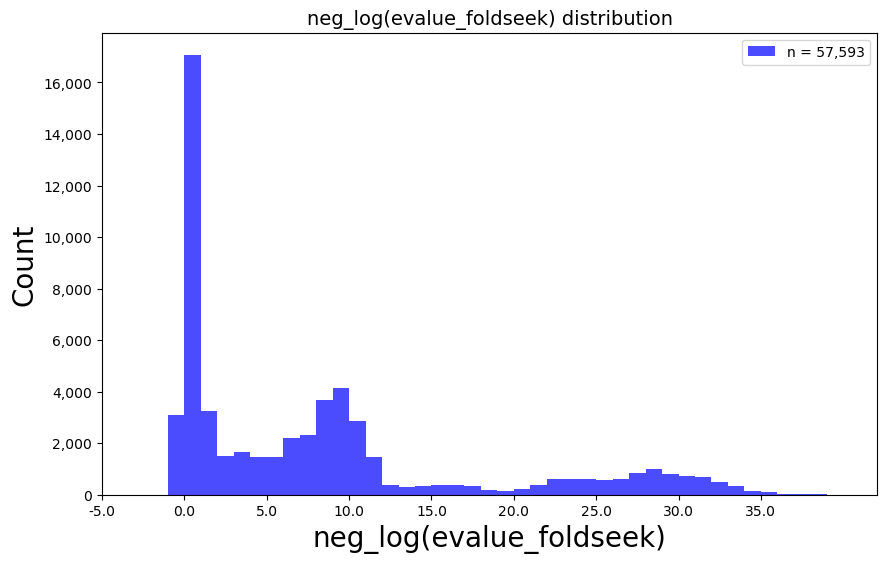

In [7]:
# ────────────────────────────────────────────────────────────
#      Plot hist: evalue_foldseek
# ────────────────────────────────────────────────────────────

# PLot histogram of `evalue_foldseek`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:

    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    logger.info(f"{col_name} max: {round(max, 4):,}")
    logger.info(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        logger.info(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        logger.info(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha=threshold_ann_side, va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_ann,
    colour="blue",
    col_name=VAR_NAME_LOG_EVALUE,
    tick_interval=5,
    bin_width=1,
    title=f"{VAR_NAME_LOG_EVALUE} distribution",
    xlabel=VAR_NAME_LOG_EVALUE,
    axis_label_fontSize=20,
    out_path=f"{OUT_DIR}/hist_{VAR_NAME_LOG_EVALUE.replace(')', '').replace('(', '')}"
)

In [8]:
# ────────────────────────────────────────────────────────────
#      PyMOL align of sample subset
# ────────────────────────────────────────────────────────────

# Generate random sample
df_tmp = df_unq_matches.sample(n=300, shuffle=True, seed=42)

# Run PyMOL super on sample
df_af, col_bact_struct, col_hs_struct = get_alphafold_structures(
    df_uniprot_ids=df_tmp,
    col_query_uniprot_id=COL_BACT_PROT_ID,
    col_target_uniprot_id=COL_HS_PROT_ID,
    out_dir=OUT_DIR_AF,
    api_endpoint=URL_AF
)

df_pm, col_pse = pymol_align_pairs(
    df_structure_files=df_af,
    col_query_id=COL_BACT_PROT_ID,
    col_query_struct=col_bact_struct,
    col_target_id=COL_HS_PROT_ID,
    col_target_struct=col_hs_struct,
    out_dir=OUT_DIR_PM,
    pymol_align_method="super",
)

df_pm.write_csv(
    f"{OUT_DIR}/n={len(df_pm)}_pymol_align.tsv",
    separator="\t",
    include_header=True,
)

df_pm

INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:https://alphafold.ebi.ac.uk/api/prediction/A0A1Z2SID7
INFO:modules.pymol_align:For A0A1Z2SID7, retrieving .pdb from https://alphafold.ebi.ac.uk/files/AF-A0A1Z2SID7-F1-model_v6.pdb...
INFO:modules.pymol_align:For A0A1Z2SID7, AlphaFold predicted structure written to /home/juliandeanmoran/___git_repos/BISSH/data_local/alphafold_structures/A0A1Z2SID7_AF.pdb.
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:https://alphafold.ebi.ac.uk/api/prediction/F5GZT0
INFO:modules.pymol_align:For F5GZT0, retrieving .pdb from https://alphafold.ebi.ac.uk/files/AF-F5GZT0-F1-model_v6.pdb...
INFO:modules.pymol_align:For F5GZT0, AlphaFold predicted structure written to /home/juliandeanmoran/___git_repos/BISSH/data_local/alphafold_structures/F5GZT0_AF.pdb.
INFO:modules.pymol_align:======================================

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),…,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(evalue_foldseek),defense_system_protein_AF_file,protein_AF_file,PyMOL_aligned_filePath,PyMOL_RMSD,PyMOL_aligned_atoms
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64,str,str,str,f64,i64
"""WP_088134450.1""","""Zorya""","""Zorya_TypeI""","""Vibrio gazogenes""","""GCF_002196515_NZ_CP018835_Zory…","""GCF_002196515.1_NZ_CP018835_03…","""GCF_002196515.1_NZ_CP018835_03…",1,202,"""A0A1Z2SID7""","""A0A1W9LKN2""","""A0A3Q0EX91""","""F5GZT0""",0.066,1,0.11,298,249,0.0,96,376,35,332,0.03259,29,"""unreviewed""","""F5GZT0_HUMAN""","""Meiotic double-stranded break …","""MEI1""","""Homo sapiens (Human)""",null,null,"""MEI1""",null,"""UP000005640: Chromosome 22""",null,null,…,null,null,"""1.25.10.10; Leucine-rich Repea…","""IPR011989; ARM-like.;""IPR01602…","""PTHR12044; BCL2 INTERACTING ME…",null,null,null,null,"""96.0..376.0""",281,506,null,null,null,null,null,null,"""35.0..332.0""",298,487,"""27..453""",69.79,100.0,61.19,"""['Zorya protein ZorC EH']""","""['ECO:0000259|Pfam:PF15611']""",0.962451,281.0,0.577002,0.037549,1.486916,"""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",18.0215,1734
"""WP_048884341.1""","""Zorya""","""Zorya_TypeI""","""Aurantiacibacter atlanticus""","""GCF_001077815_NZ_CP011310_Zory…","""GCF_001077815.2_NZ_CP011310_00…","""GCF_001077815.2_NZ_CP011310_00…",1,202,"""A0A0H4VDC2""","""A0A101WRB2""","""L8LWH0""","""B3KPF2""",0.8219,2,0.17,86,56,0.0,155,240,1116,1184,2.627,5,"""unreviewed""","""B3KPF2_HUMAN""","""dynamin GTPase (EC 3.6.5.5)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""endocytosis [GO:0006897]""","""microtubule [GO:0005874]""",…,"""cd08771; DLP_1; 1.;""","""1.20.120.1240:FF:000014; Dynam…","""1.20.120.1240; Dynamin, middle…","""IPR022812; Dynamin.;""IPR001401…","""PTHR11566; DYNAMIN; 1.;""PTHR11…","""PF01031; Dynamin_M; 1.;""PF0035…","""PS00410; G_DYNAMIN_1; 1.;""PS51…","""SM00053; DYNc; 1.;""",null,"""155.0..240.0""",86,555,"""28..294""",32.21,100.0,15.5,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""1116.0..1184.0""",69,1243,null,null,null,null,null,null,2.23964,69.0,0.124324,1.23964,-0.41946,"""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",24.708685,567
"""WP_013220829.1""","""Zorya""","""Zorya_TypeI""","""Nitrosococcus watsonii""","""GCF_000143085_NC_014315_Zorya_…","""GCF_000143085.1_NC_014315_0187…","""GCF_000143085.1_NC_014315_0187…",1,202,"""D8K760""","""A0A2D9ZZN8""","""B3RZ88""","""Q99705""",0.03944,1,0.083,363,301,0.0,88,416,1,363,0.5326,11,"""reviewed""","""MCHR1_HUMAN""","""Melanin-concentrating hormone …","""MCHR1 GPR24 SLC1""","""Homo sapiens (Human)""",null,null,"""MCHR1""","""GPR24 SLC1""","""UP000005640: C

In [15]:
# ────────────────────────────────────────────────────────────
#       Out
# ────────────────────────────────────────────────────────────

df_pm.write_csv(
    f"{OUT_DIR}/zorya_pymol_ann_n={len(df_pm)}.tsv",
    separator="\t",
    include_header=True
)

In [14]:
OUT_DIR

PosixPath('/home/juliandeanmoran/___git_repos/BISSH/results/explore_zorya')

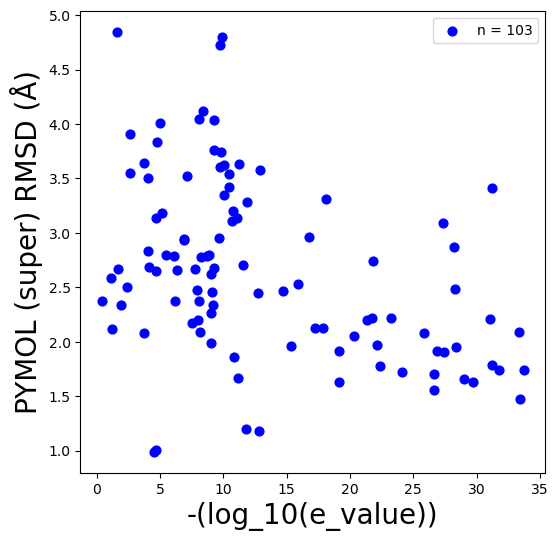

In [9]:
# ────────────────────────────────────────────────────────────
#       Scatter: foldseek_evalue v. PyMOL RMSD
# ────────────────────────────────────────────────────────────

df_forPlot = df_pm.filter(
    (pl.col("PyMOL_RMSD") <= 5.0)
)

def plot_scatter(
    df: pl.DataFrame,
    col_x: str,
    col_y: str,
    colour_col: str = None,
    plot_title: str = "",
    title_font_size: int = 14,
    y_axis_label: str = "Y",
    x_axis_label: str = "X",
    axis_equal_aspect_ratio = False,
    dot_size: float = 40,
    dot_colour: str = "blue",
    cmap: str = "viridis",
    dot_alpha: float = 1.0,
    threshold: float = None,
    axis_label_font_size: int = 20,
    dims: tuple[int, int] = (6, 6),
    out_path = None,
) -> None:

    x = df[col_x].to_numpy()
    y = df[col_y].to_numpy()

    fig, ax = plt.subplots(figsize=dims)

    if colour_col is not None:
        c = df[colour_col].to_numpy()
        sc = ax.scatter(
            x,
            y,
            c=c,
            cmap=cmap,
            s=dot_size,
            alpha=dot_alpha,
            label=f"n = {len(df)}"
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label(colour_col)

        # ensure full range is shown
        sc.set_clim(c.min(), c.max())

    else:
        ax.scatter(x, y, s=dot_size, c=dot_colour, alpha=dot_alpha, label=f"n = {len(df)}")
    
    ax.legend()

    if axis_equal_aspect_ratio:
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        low = min(xmin, ymin)
        high = max(xmax, ymax)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    if threshold is not None:
        ax.axvline(threshold, linestyle="--", color="red")
        ax.axhline(threshold, linestyle="--", color="red")

    ax.set_title(plot_title, fontsize=title_font_size)
    ax.set_xlabel(x_axis_label, fontsize=axis_label_font_size)
    ax.set_ylabel(y_axis_label, fontsize=axis_label_font_size)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()


plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    x_axis_label=f'-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    threshold=None,
    dot_colour="blue",
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_n={len(df_forPlot)}",
)

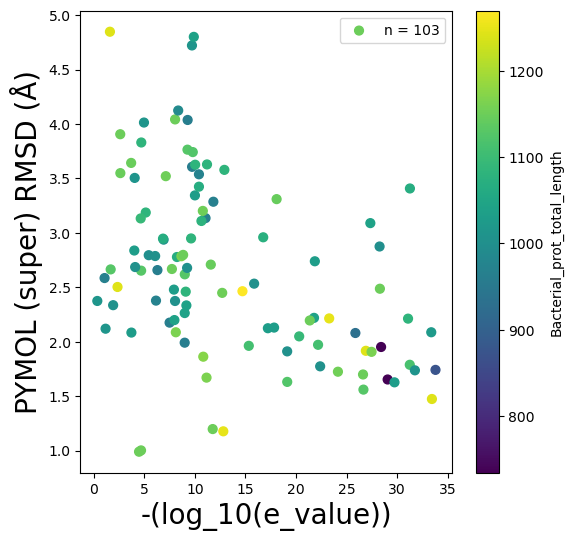

In [10]:
# ────────────────────────────────────────────────────────────
#       Scatter: colour by bacterial protein length
# ────────────────────────────────────────────────────────────

plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    colour_col="Bacterial_prot_total_length",
    x_axis_label='-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_bactAA_n={len(df_forPlot)}",
)

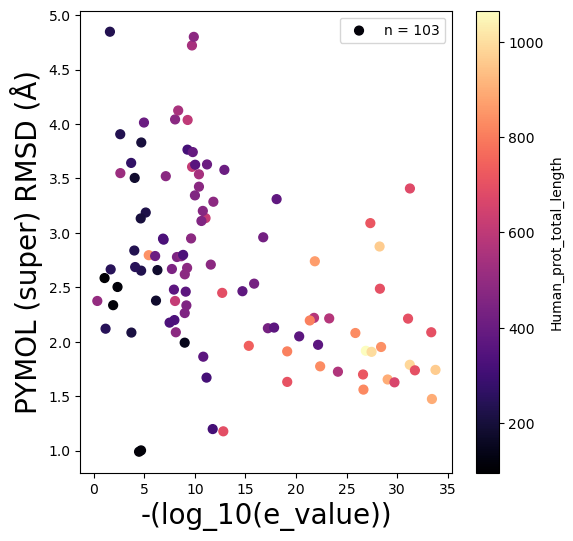

In [11]:
# ────────────────────────────────────────────────────────────
#       Scatter: colour by H.s. protein length
# ────────────────────────────────────────────────────────────

plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    colour_col="Human_prot_total_length",
    cmap="magma",
    x_axis_label='-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_hsAA_n={len(df_forPlot)}",
)

- `alnlen`: as I understand, this field represents global TM-align score as computed by FoldSeek

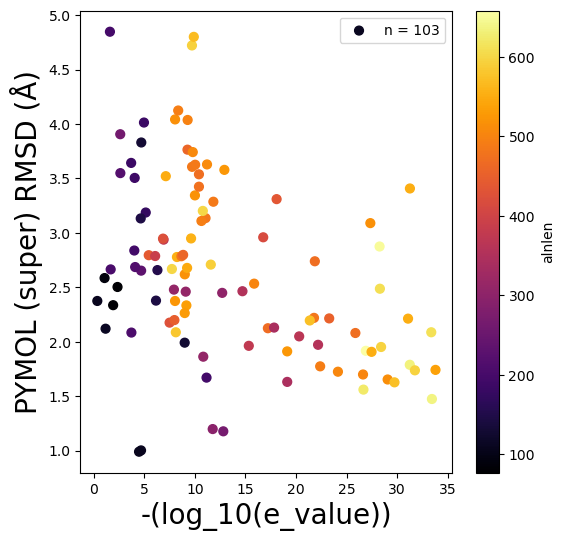

In [12]:
# ────────────────────────────────────────────────────────────
#       Scatter: colour by protein alignment length
# ────────────────────────────────────────────────────────────

plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    colour_col="alnlen",
    cmap="inferno",
    x_axis_label='-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_tmLen_n={len(df_forPlot)}",
)

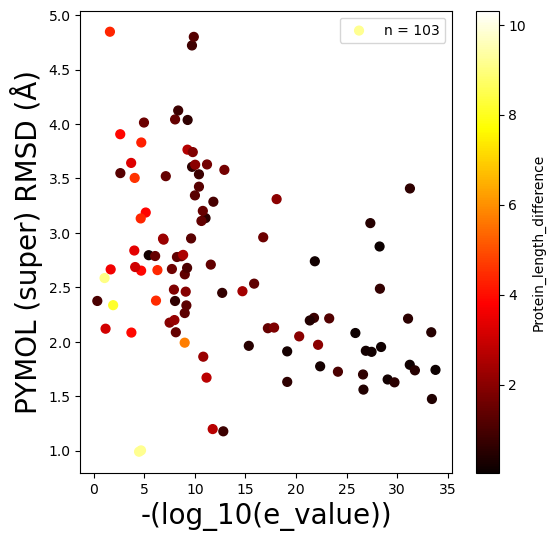

In [13]:
# ────────────────────────────────────────────────────────────
#       Scatter: colour by protein length difference
# ────────────────────────────────────────────────────────────

plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    colour_col=VAR_NAME_LENGTH_ERROR,
    cmap="hot",
    x_axis_label='-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_protLenDiff_n={len(df_forPlot)}",
)

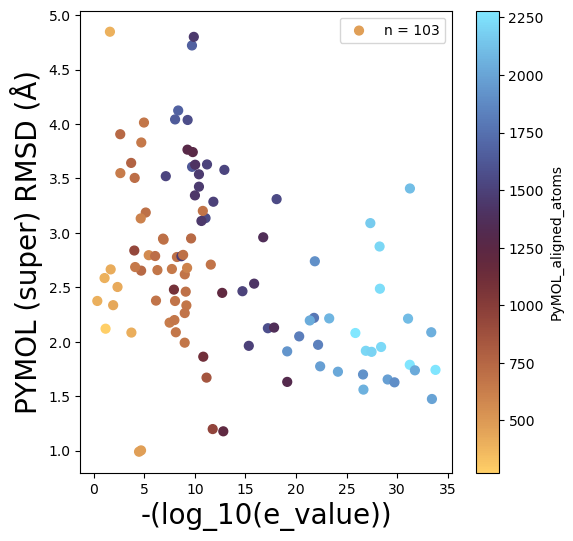

In [18]:
# ────────────────────────────────────────────────────────────
#       Scatter: colour by protein length difference
# ────────────────────────────────────────────────────────────

plot_scatter(
    df=df_forPlot,
    col_x=VAR_NAME_LOG_EVALUE,
    col_y="PyMOL_RMSD",
    colour_col="PyMOL_aligned_atoms",
    cmap="managua",
    x_axis_label='-(log_10(e_value))',
    y_axis_label=f'PYMOL ({PYMOL_ALIGN_METHOD}) RMSD (Å)',
    out_path=f"{OUT_DIR}/scatter_evalue_pymol-{PYMOL_ALIGN_METHOD}_pmLen_n={len(df_forPlot)}",
)

In [104]:
# ────────────────────────────────────────────────────────────
#      Filter: same cluster status
# ────────────────────────────────────────────────────────────

def filter_data_same_cluster(
        df: pl.DataFrame,
) -> pl.DataFrame:
    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    logger.info(f"N rows after filtering: {len(df)}")
    return df


df_filt = filter_data_same_cluster(
    df=df_ann
)
df_filt.write_csv(
    f"{OUT_DIR}/n={len(df_filt)}_zorya_filt.tsv",
    separator="\t",
    include_header=True
)
df_filt

INFO:__main__:N rows after filtering: 297


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_012123970.1""","""Zorya""","""Zorya_TypeI""","""Cronobacter sakazakii""","""GCF_018884145_NZ_CP049150_Zory…","""GCF_018884085.1_NZ_CP049147_03…","""GCF_018884085.1_NZ_CP049147_03…",3,200,"""A7MEH1""","""A0A7S4UXI5""","""A0A7S4UXI5""","""B3KX98""",0.0,2,0.212,179,133,0.0,705,874,899,1077,1.2940e-7,260,"""unreviewed""","""B3KX98_HUMAN""","""cDNA FLJ45012 fis, clone BRAWH…",null,"""Homo sapiens (Human)""",null,null,null,null,null,null,"""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; heli…","""GO:0004386; GO:0005524; GO:000…","""cd16569; RING-HC_SHPRH-like; 1…","""3.30.40.10:FF:000162; E3 ubiqu…","""3.40.50.300; P-loop containing…","""IPR052583; ATP-helicase/E3_Ub-…","""PTHR45865:SF1; E3 UBIQUITIN-PR…","""PF00271; Helicase_C; 1.;""PF213…","""PS51194; HELICASE_CTER; 1.;""PS…","""SM00490; HELICc; 1.;""SM00184; …","""NP_001036148.2; NM_001042683.2…","""705.0..874.0""",170,882,"""713..871""",100.0,93.53,19.27,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""899.0..1077.0""",179,1080,"""904..1069""",100.0,92.74,16.57,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",1.22449,170.0,0.192744,0.22449,6.888066
"""WP_128105540.1""","""Zorya""","""Zorya_TypeI""","""Acetobacter oryzoeni""","""GCF_004014775_NZ_CP042808_Zory…","""GCF_004014775.2_NZ_CP042808_01…","""GCF_004014775.2_NZ_CP042808_01…",1,202,"""A0A5B9GHV7""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.196,657,524,0.0,370,1026,362,1014,9.7780e-28,762,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""370.0..1026.0""",657,1026,"""509..677""",100.0,25.72,64.04,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""362.0..1014.0""",653,1028,"""505..697""",100.0,29.56,63.52,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.001949,653.0,0.636452,0.001949,27.00975
"""WP_141991876.1""","""Zorya""","""Zorya_TypeI""","""Acinetobacter baumannii""","""

INFO:__main__:Protein_length_difference max: 0.2404
INFO:__main__:Protein_length_difference min: 0.001


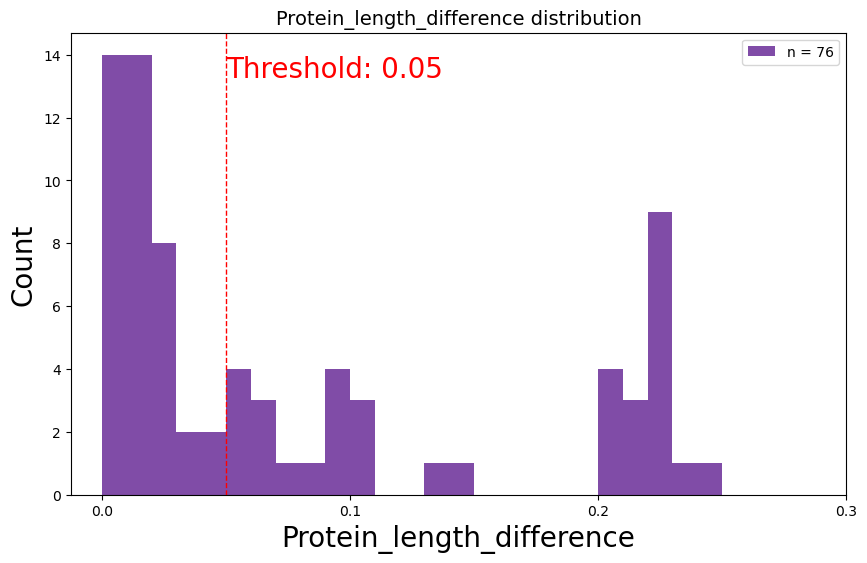

In [107]:
# ────────────────────────────────────────────────────────────
#      Plot hist: length difference
# ────────────────────────────────────────────────────────────

plot_hist(
    df=df_unq_matches,
    colour="indigo",
    col_name=VAR_NAME_LENGTH_ERROR,
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{VAR_NAME_LENGTH_ERROR} distribution",
    xlabel=VAR_NAME_LENGTH_ERROR,
    out_path=f"{OUT_DIR}/hist_{VAR_NAME_LENGTH_ERROR}",
    threshold=THRESHOLD_LENGTH_ERROR,
    axis_label_fontSize=20
)

INFO:__main__:Overlap_ratio max: 0.7529
INFO:__main__:Overlap_ratio min: 0.1678


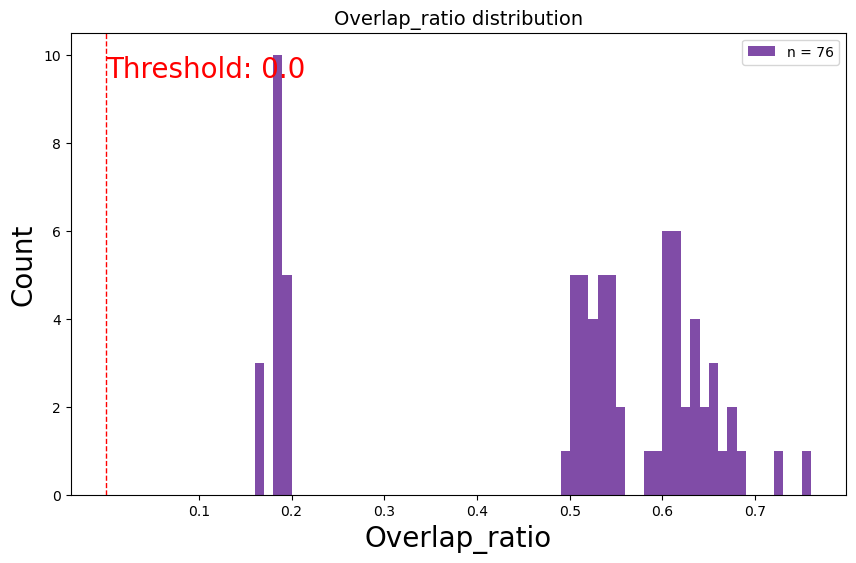

In [108]:
# ────────────────────────────────────────────────────────────
#      Plot hist: Overlap ratio
# ────────────────────────────────────────────────────────────

plot_hist(
    df=df_unq_matches,
    col_name="Overlap_ratio",
    colour="indigo",
    tick_interval=0.1,
    bin_width=0.01,
    title=f"Overlap_ratio distribution",
    xlabel="Overlap_ratio",
    axis_label_fontSize=20,
    out_path=f"{OUT_DIR}/hist_Overlap_ratio",
    threshold=THRESHOLD_OVERLAP_RATIO,
    threshold_ann_side="left"
)

In [109]:
# ────────────────────────────────────────────────────────────
#      Filter by annotations
# ────────────────────────────────────────────────────────────

def filter_extra_metrics(
        df: pl.DataFrame,
        var_length_error: str,
        threshold_length_error: float,
        threshold_overlap_ratio: float
) -> pl.DataFrame:
    
    df = df.filter(
        (pl.col(var_length_error) <= threshold_length_error) &
        (pl.col("Overlap_ratio") >= threshold_overlap_ratio)
    )

    logger.info(f"N rows after filtering by extra metrics: {len(df)}")
    return df

df_ann_filt = filter_extra_metrics(
    df=df_unq_matches,
    var_length_error=VAR_NAME_LENGTH_ERROR,
    threshold_length_error=THRESHOLD_LENGTH_ERROR,
    threshold_overlap_ratio=THRESHOLD_OVERLAP_RATIO
)

df_ann_filt.write_csv(
    f"{OUT_DIR}/zorya_unique_protein_pairs_filt_n={len(df_ann_filt)}.tsv",
    separator="\t",
    include_header=True
)

summarise_protein_matches(
    df_ann_filt,
    col_bact_prot_id=COL_BACT_PROT_ID,
    col_human_prot_id=COL_HS_PROT_ID,
    col_cluster_id=COL_CLUSTER_ID
)

INFO:__main__:N rows after filtering by extra metrics: 40
INFO:__main__:N protein matches: 40
INFO:__main__:N unique clusters: 1
INFO:__main__:N unique protein pairs: 40
INFO:__main__:shape: (1,)
Series: 'cluster_id' [str]
[
	"A0A355UP19"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(foldseek_evalue)
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64
"""WP_109992022.1""","""Zorya""","""Zorya_TypeI""","""Salinisphaera sp. LB1""","""GCF_003177035_NZ_CP029488_Zory…","""GCF_003177035.1_NZ_CP029488_00…","""GCF_003177035.1_NZ_CP029488_00…",1,202,"""A0A2Z3J444""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.213,631,459,0.0,307,937,404,987,2.6750e-33,923,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""307.0..937.0""",631,1014,"""451..625""",100.0,27.73,62.23,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""404.0..987.0""",584,989,"""815..984""",100.0,29.11,59.05,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.975345,584.0,0.590495,0.024655,32.572676
"""WP_099775859.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas sp. HLS-6""","""GCF_002753995_NZ_CP024478_Zory…","""GCF_002753995.1_NZ_CP024478_04…","""GCF_002753995.1_NZ_CP024478_04…",1,202,"""A0A2D2MBG9""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.207,586,444,0.0,466,1026,427,1012,2.3000e-27,877,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""466.0..1026.0""",561,1026,"""509..677""",100.0,30.12,54.68,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""427.0..1012.0""",586,1012,"""479..687""",100.0,35.67,57.91,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.986355,561.0,0.554348,0.013645,26.638272
"""WP_151184585.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas sp. C27(201

In [32]:
type(VAR_NAME_LENGTH_ERROR)

str